# Optimizing a structural parameter

The single-cell notebook tunes only values the simulator reads at run time, so the SONATA network
is built once and every trial reuses it. This one tunes a **structural** parameter as well, which
is the other half of the story.

Two dimensions:

| dimension | kind | consequence |
|---|---|---|
| `conn.syn_weight` | **structural** — written into `edge_types.csv` | the network must be rebuilt for every candidate |
| `exc.nest_params.I_e` | runtime — written to `<pop_name>_params.json` | no rebuild on its own |

Because one dimension is structural, **every trial rebuilds**. That is correct, not a regression:
each candidate really is a different network. The copy the engine seeds into each trial is simply
discarded. The last cell counts rebuilds so you can see it.

A limitation to know: addresses index dicts, not lists, so a weight inside `connections[0]` cannot
be tuned. Only the node-level `syn_weight` default is addressable — and it applies to every
connection that does not override it.

In [1]:
import contextlib
import io
import os
import sys

# Prefer this repository's sources over any previously installed copy:
# neuroworkflow.optimization is new and an older install would not have it.
sys.path.insert(0, os.path.abspath('../src'))

from neuroworkflow import WorkflowBuilder
from neuroworkflow.nodes.network.NW_Population      import NW_Population
from neuroworkflow.nodes.network.NW_Connectivity    import NW_Connectivity
from neuroworkflow.nodes.simulation.NW_SimConfig    import NW_SimConfig
from neuroworkflow.nodes.analysis.NW_Analysis       import NW_Analysis

from neuroworkflow.optimization import AlgorithmConfig, build_spec, optimize

## 1. Nodes

In [2]:
exc  = NW_Population("exc")
inh  = NW_Population("inh")
conn = NW_Connectivity("conn")
sim  = NW_SimConfig("sim")
ana  = NW_Analysis("ana")

## 2. Configure

A small E-I network. Note which connections carry an explicit `syn_weight` and which do not:
the two **excitatory** projections omit it, so they inherit the node-level default — the value the
optimizer will tune. The inhibitory projections fix their own weight and stay constant.

In [3]:
neuron = dict(
    model_type="point_neuron", model_template="nest:iaf_psc_alpha",
    location="VISp", layer="L4",
    nest_params={"C_m": 250.0, "tau_m": 10.0, "t_ref": 2.0,
                 "V_th": -55.0, "V_reset": -70.0, "E_L": -70.0, "I_e": 370.0},
    # 370 pA sits just under this neuron's threshold: C_m/tau_m = 25 nS and
    # V_th - E_L = 15 mV, so it cannot spike below 15 mV x 25 nS = 375 pA.
    # The network therefore starts silent and the search has to find the drive
    # that wakes it - which is the point of the example.
)
exc.configure(pop_name="exc", N=16, ei_type="exc", **neuron)
inh.configure(pop_name="inh", N=4,  ei_type="inh", **neuron)

In [4]:
conn.configure(
    connection_rule = 1,        # one synapse per pair - deterministic, no RNG noise in the objective
    syn_weight      = 5.0,      # node-level default: inherited by connections that omit it
    connections = [
        {"source": "exc", "target": "exc"},                      # tuned
        {"source": "exc", "target": "inh"},                      # tuned
        {"source": "inh", "target": "exc", "syn_weight": -40.0}, # fixed
        {"source": "inh", "target": "inh", "syn_weight": -40.0}, # fixed
    ],
)

In [5]:
sim.configure(simulator="pointnet", config_file="config_net_opt.json",
              tstop_ms=500.0, dt_ms=0.1)
ana.configure(plot_raster=False, plot_traces=False)

## 3. Build

In [6]:
wf = WorkflowBuilder("NW_Network_Optimization")
for node in [exc, inh, conn, sim, ana]:
    wf.add_node(node)

wf.connect("exc",  "population", "conn", "populations")
wf.connect("inh",  "population", "conn", "populations")
wf.connect("conn", "network",    "sim",  "populations")
wf.connect("sim",  "results",    "ana",  "results")

wf.context["results_path"] = "./results/net_opt"
workflow = wf.build()
print("nodes:", list(workflow.nodes))

nodes: ['exc', 'inh', 'conn', 'sim', 'ana']


## 4. Declare what to optimize

`conn.syn_weight` is a plain scalar parameter, so its range is `[min, max]`. `exc.nest_params.I_e`
is a key inside a dict, so it is declared per key.

In [7]:
explore_conn_syn_weight = conn.NODE_DEFINITION.parameters["syn_weight"]
explore_conn_syn_weight.optimizable        = True
explore_conn_syn_weight.optimization_range = [0.0, 30.0]     # pA, current-based synapses
explore_conn_syn_weight.unit               = "pA"

explore_exc_nest_params = exc.NODE_DEFINITION.parameters["nest_params"]
explore_exc_nest_params.optimizable        = True
explore_exc_nest_params.optimization_range = {"I_e": [370.0, 450.0]}   # pA, straddles the 375 pA threshold

target_exc_mean_firing_rate = exc.NODE_DEFINITION.parameters["mean_firing_rate"]
target_exc_mean_firing_rate.unit            = "Hz"
target_exc_mean_firing_rate.is_objective    = True
target_exc_mean_firing_rate.objective_range = [28.0, 32.0]   # a narrow slice of the
# reachable range, so the search has to work for it rather than stumbling in
target_exc_mean_firing_rate.measures        = (
    f"{ana.name}.firing_rate_hz.{exc._parameters['pop_name']}"
)

print("target measures:", target_exc_mean_firing_rate.measures)

target measures: ana.firing_rate_hz.exc


## 5. Spec

`exc` and `inh` are two instances of the same class, and each carries its **own** copy of its
definition — so marking `nest_params` optimizable on `exc` leaves `inh` untouched. Check the
summary: only `exc.nest_params.I_e` should appear.

In [8]:
spec = build_spec(
    workflow,
    algorithm=AlgorithmConfig(name="cmaes", pop_size=4, max_generations=6, seed=1),
)

print("baseline measurables:")
for address, value in sorted(spec.baseline["measurables"].items()):
    print(f"   {address:<40} {value:g}")
print()
print(spec.summary())

Executing node: inh
Executing node: exc
Executing node: conn
Executing node: sim
[NW_SimConfig] network unchanged, reusing ./results/net_opt/network

              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Mar  4 2025 17:27:39

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

2026-09-07 09:48:49,545 [INFO] Created log file


INFO:NestIOUtils:Created log file


2026-09-07 09:48:49,553 [INFO] Batch processing nodes for exc/0.


INFO:NestIOUtils:Batch processing nodes for exc/0.


2026-09-07 09:48:49,557 [INFO] Batch processing nodes for inh/0.


...

2026-09-07 09:48:49,623 [INFO] Simulation finished, finalizing results.


INFO:NestIOUtils:Simulation finished, finalizing results.


2026-09-07 09:48:49,642 [INFO] Done.


INFO:NestIOUtils:Done.


Executing node: ana
baseline measurables:
   ana.firing_rate_hz.exc                   0
   ana.firing_rate_hz.inh                   0
   ana.isi_stats.exc.cv                     0
   ana.isi_stats.exc.mean_ms                0
   ana.isi_stats.exc.n_intervals            0
   ana.isi_stats.exc.std_ms                 0
   ana.isi_stats.inh.cv                     0
   ana.isi_stats.inh.mean_ms                0
   ana.isi_stats.inh.n_intervals            0
   ana.isi_stats.inh.std_ms                 0

algorithm : cmaes (pop_size=4, max_generations=6)
dimensions: 2
    exc.nest_params.I_e                      [370.0, 450.0]
    conn.syn_weight                          [0.0, 30.0] pA
objectives: 1
    exc.mean_firing_rate                     in [28.0, 32.0] Hz  <- ana.firing_rate_hz.exc


## 6. Run

Output is captured so the per-trial NEST and BMTK logs do not bury the result; the engine's own
narration is printed afterwards, followed by a count of rebuilds versus reuses.

In [10]:
buffer = io.StringIO()
with contextlib.redirect_stdout(buffer):
    result = optimize(workflow, spec=spec, results_path="./results/net_opt/optimization")
captured = buffer.getvalue()

for line in captured.splitlines():
    if line.startswith("[opt_") or line.lstrip().startswith("gen ") or line.startswith("  reusing"):
        print(line)

built  = captured.count("network built")
reused = captured.count("network unchanged")
print(f"\nnetwork rebuilt in {built} runs, reused in {reused}")
print("expected: rebuilt on every trial, because syn_weight is structural")

2026-09-07 09:49:10,271 [INFO] Created log file


INFO:NestIOUtils:Created log file


2026-09-07 09:49:10,275 [INFO] Batch processing nodes for exc/0.


INFO:NestIOUtils:Batch processing nodes for exc/0.


2026-09-07 09:49:10,279 [INFO] Batch processing nodes for inh/0.


...

2026-09-07 09:49:11,315 [INFO] Simulation finished, finalizing results.


INFO:NestIOUtils:Simulation finished, finalizing results.


2026-09-07 09:49:11,341 [INFO] Done.


INFO:NestIOUtils:Done.


[opt_20260907_094910] cmaes: 2 dimensions, 1 objective(s), up to 6 generations x 4 candidates
  reusing network from results/net_opt/optimization/opt_20260907_094850/trials/0008
  gen 1, trial 1/4 (#1): exc.nest_params.I_e=403.4  conn.syn_weight=21.61 pA  ->  mean_firing_rate=38 Hz (off 6 Hz)   <- best so far
  gen 1, trial 2/4 (#2): exc.nest_params.I_e=370  conn.syn_weight=9.07 pA  ->  mean_firing_rate=0 Hz (off 28 Hz)
  gen 1, trial 3/4 (#3): exc.nest_params.I_e=381.7  conn.syn_weight=2.77 pA  ->  mean_firing_rate=20 Hz (off 8 Hz)
  gen 1, trial 4/4 (#4): exc.nest_params.I_e=384.9  conn.syn_weight=10.37 pA  ->  mean_firing_rate=24 Hz (off 4 Hz)   <- best so far
  gen 1/6: best exc.nest_params.I_e=384.9  conn.syn_weight=10.37 pA  ->  mean_firing_rate=24 Hz [target 28.0-32.0 Hz, off 4 Hz]
  gen 2, trial 1/4 (#5): exc.nest_params.I_e=430.5  conn.syn_weight=24.75 pA  ->  mean_firing_rate=52 Hz (off 20 Hz)
  gen 2, trial 2/4 (#6): exc.nest_params.I_e=380.2  conn.syn_weight=19.25 pA  ->  m

## 7. Result

In [11]:
print("stop reason:", result.stop_reason)
if result.best:
    print("best trial:", result.best["trial"])
    for address, value in result.best["params"].items():
        print(f"  {address:<34} {value:.4g}")
    print("  measured:", result.best["measured"])
    print("  distance from target (raw, per objective):", result.best["fitness"])
    print()
    print(result.configure_snippet())

stop reason: a candidate is inside every target band
best trial: 8
  exc.nest_params.I_e                393.4
  conn.syn_weight                    7.099
  measured: {'exc.mean_firing_rate': 28.0}
  distance from target (raw, per objective): [0.0]

conn.configure(syn_weight=7.098638567167976)
exc.configure(nest_params={**exc._parameters["nest_params"], "I_e": 393.42826106245246})


## 8. How the search evolved

Same three views as the single-cell notebook: measured value against the target band, fitness with
the best-so-far curve, and each dimension coloured by fitness.

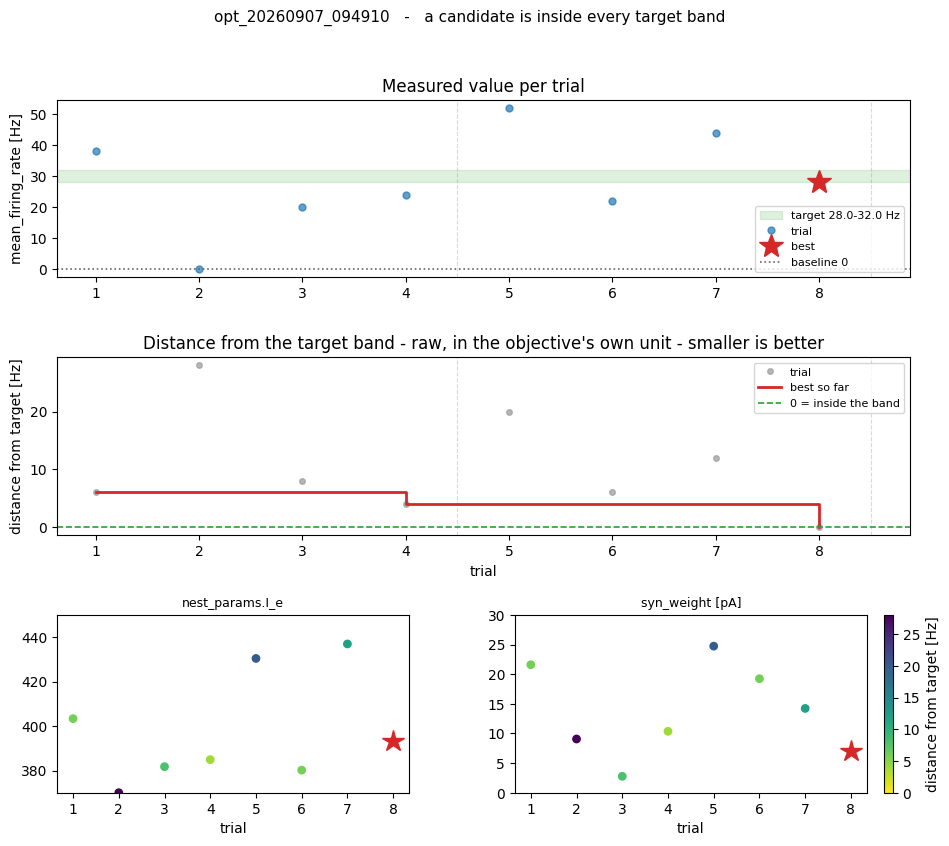

In [12]:
import matplotlib.pyplot as plt

trials    = result.trials
objective = spec.objectives[0]
scored    = [t for t in trials if t["fitness"] is not None]

if not scored:
    print("no successful trial to plot")
else:
    x        = [t["trial"] for t in scored]
    measured = [t["measured"][objective.name] for t in scored]
    # One objective, so this is simply how far it missed, in its own unit.
    # With several objectives use t["target_ranges_off"] instead: misses in different
    # units cannot be compared until each is sized against its own target range.
    fitness  = [t["fitness"][0] for t in scored]
    best_so_far, running = [], float("inf")
    for value in fitness:
        running = min(running, value)
        best_so_far.append(running)
    best_trial = result.best["trial"]
    pop_size   = spec.algorithm.pop_size
    dims       = spec.dimensions

    fig  = plt.figure(figsize=(11, 9))
    grid = fig.add_gridspec(3, max(len(dims), 1), hspace=0.45, wspace=0.3)
    ax_measured = fig.add_subplot(grid[0, :])
    ax_fitness  = fig.add_subplot(grid[1, :])
    dim_axes    = [fig.add_subplot(grid[2, i]) for i in range(len(dims))]

    def generations(ax):
        for boundary in range(pop_size, max(x) + 1, pop_size):
            ax.axvline(boundary + 0.5, color="0.85", lw=0.8, ls="--", zorder=0)

    ax_measured.axhspan(objective.low, objective.high, color="tab:green", alpha=0.15,
                        label=f"target {objective.low}-{objective.high} {objective.unit}")
    generations(ax_measured)
    ax_measured.plot(x, measured, "o", ms=5, color="tab:blue", alpha=0.7, label="trial")
    ax_measured.plot(best_trial, result.best["measured"][objective.name], "*",
                     ms=18, color="tab:red", label="best", zorder=5)
    baseline = spec.baseline.get("measured", {}).get(objective.name)
    if baseline is not None:
        ax_measured.axhline(baseline, color="0.4", ls=":", lw=1.2,
                            label=f"baseline {baseline:.3g}")
    ax_measured.set_ylabel(f"{objective.name.split('.')[-1]} [{objective.unit}]")
    ax_measured.set_title("Measured value per trial")
    ax_measured.legend(fontsize=8, loc="best")

    generations(ax_fitness)
    ax_fitness.plot(x, fitness, "o", ms=4, color="0.6", alpha=0.7, label="trial")
    ax_fitness.step(x, best_so_far, where="post", color="tab:red", lw=2, label="best so far")
    ax_fitness.axhline(0.0, color="tab:green", lw=1.2, ls="--", label="0 = inside the band")
    ax_fitness.set_xlabel("trial")
    ax_fitness.set_ylabel(f"distance from target [{objective.unit}]"
                          if objective.unit else "distance from target")
    ax_fitness.set_title("Distance from the target band - raw, in the objective's "
                         "own unit - smaller is better")
    ax_fitness.legend(fontsize=8, loc="best")

    points = None
    for ax, dimension in zip(dim_axes, dims):
        values = [t["params"][dimension.address] for t in scored]
        points = ax.scatter(x, values, c=fitness, cmap="viridis_r", s=28)
        ax.plot(best_trial, result.best["params"][dimension.address], "*",
                ms=16, color="tab:red", zorder=5)
        ax.set_ylim(dimension.low, dimension.high)
        ax.set_xlabel("trial")
        ax.set_title(dimension.address.split(".", 1)[1] +
                     (f" [{dimension.unit}]" if dimension.unit else ""), fontsize=9)
    if points is not None:
        fig.colorbar(points, ax=dim_axes, fraction=0.03, pad=0.02,
                     label=f"distance from target [{objective.unit}]"
                           if objective.unit else "distance from target")

    fig.suptitle(f"{result.run_id}   -   {result.stop_reason}", fontsize=11)
    plt.show()

## 9. Adopt the winner

In [13]:
result.apply_best(workflow, execute=True)
print("syn_weight  =", conn._parameters["syn_weight"])
print("I_e         =", exc._parameters["nest_params"]["I_e"])
print("firing rate =", ana._output_ports["firing_rate_hz"].value)

Executing node: inh
Executing node: exc
Executing node: conn
Executing node: sim
[NW_SimConfig] network unchanged, reusing results/net_opt/optimization/opt_20260907_094910/trials/0008/network
2026-09-07 09:49:24,693 [INFO] Created log file


INFO:NestIOUtils:Created log file


2026-09-07 09:49:24,701 [INFO] Batch processing nodes for exc/0.


INFO:NestIOUtils:Batch processing nodes for exc/0.


2026-09-07 09:49:24,705 [INFO] Batch processing nodes for inh/0.


...

2026-09-07 09:49:24,776 [INFO] Simulation finished, finalizing results.


INFO:NestIOUtils:Simulation finished, finalizing results.


2026-09-07 09:49:24,802 [INFO] Done.


INFO:NestIOUtils:Done.


Executing node: ana
syn_weight  = 7.098638567167976
I_e         = 393.42826106245246
firing rate = {'exc': 28.0, 'inh': 28.0}


## Notes

- **Every trial rebuilt the network**, unlike the single-cell notebook. That is the honest cost of
  tuning something written into the SONATA files: each candidate is a different network. The
  signature check is still doing its job — it correctly says "this changed".
- **Only the excitatory projections were tuned**, because the inhibitory ones set their own
  `syn_weight` and a per-connection value overrides the node default.
- **`inh` was unaffected by the declarations on `exc`**, since each node instance owns its
  definition.
- If the search pins against `syn_weight = 30` or `0`, widen the range; the target band may be
  unreachable with the fixed inhibitory weight.